---
# Please replace all placeholder text in quotes before publishing. Remove the quotes too.
title: Evaluating the added benefits of data integration using Bayesian model comparison tools
short_title: Assessing data integration approaches  # shows up in left side bar table of contents
description: Data from multiple sources that measure the same latent process can be modelled separately or combined and modelled together. We lay out a method to assess which approach leads to better predictive accuracy.
  
date: 2026-09-28  # date of first publication
updated: 2026-09-28  # date of latest update

license:
  code: CC-BY-4.0  # from https://spdx.org/licenses/
  content: CC-BY-4.0 # from https://spdx.org/licenses/

github: https://github.com/JoeAWilde/ds-toolbox-notebook-dataintegration.git  # repository of your notebook
# thumbnail: "../images/edsb-favicon.png"  # used on other pages to link to your notebook

authors:
  - name: Joe A. Wilde
    orcid: 0000-0001-9189-1811
    corresponding: true  # for corresponding author, otherwise change to false
    email: joe.wilde@bioss.ac.uk
    affiliations:
      - name: Biomathematics and Statistical Scotland
        ror: https://ror.org/03jwrz939  # if it is a research organisation, from https://ror.org/

  - name: John Addy
    corresponding: false  # for corresponding author, otherwise change to false
    email: john.addy@bioss.ac.uk
    affiliations:
      - name: Biomathematics and Statistical Scotland
        ror: https://ror.org/03jwrz939  # if it is a research organisation, from https://ror.org/

  - name: Catriona Morrison
    corresponding: false  # for corresponding author, otherwise change to false
    orcid: 0000-0002-4293-2717
    email: catriona.morrison@bioss.ac.uk
    affiliations:
      - name: Biomathematics and Statistical Scotland
        ror: https://ror.org/03jwrz939  # if it is a research organisation, from https://ror.org/

  - name: David L Miller
    corresponding: false  # for corresponding author, otherwise change to false
    orcid: 0000-0002-9640-6755
    email: dave.miller@bioss.ac.uk
    affiliations:
      - name: Biomathematics and Statistical Scotland
        ror: https://ror.org/03jwrz939  # if it is a research organisation, from https://ror.org/

      - name: UK Centre for Ecology & Hydrology
        ror: https://ror.org/00pggkr55  # if it is a research organisation, from https://ror.org/

funding:
  - statement: Funded as part of the BioSS-UKCEH methods development framework. 

---

# Evaluating the added benefits of data integration using Bayesian model comparison tools

## Summary

* Datasets from multiple monitoring schemes can be combined to share information about latent processes, sometimes enabling better model predictions.

* Adding lower-quality, noisy, or conflicting data sources does not always lead to better inference and can introduce unaccounted bias.

* We establish an out-of-sample predictive validation framework using leave-one-out expected log pointwise predictive density ($\mathrm{ELPD_{LOO}}$) and Pseudo-Bayesian Model Average (Pseudo-BMA) weighting to quantify when data integration improves predictive ability.


::::{tab-set}
:::{tab-item} Hardware Requirements
:sync: tab1
The analysis can be run on a computer with any modern CPU and RAM. The script as written assumes at least a 4-core CPU as it leverages parallelisation as part of the MCMC sampling. To ammend this change the `cores = 4` argument throughout. Disk space requirements are minimal (< 5 GB) to store fitted model objects, compiled C++ binaries, and posterior draw outputs.
:::
:::{tab-item} Software Requirements
:sync: tab2
* R (version $\ge$ 4.2.0) running in a standard IDE (e.g., RStudio / VS Code).
* JAGS: Standalone JAGS engine (version $\ge$ 4.3.0) and the R interface package JAGSUI.
* brms: version $\ge$ 2.20.0, which requires a functional C++ toolchain (Rtools on Windows, macOS R toolchain, or gcc/clang on Linux) along with cmdstanr (recommended) or rstan as the underlying backend engine.
* loo: version $\ge$ 2.6.0 for Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO).
:::
:::{tab-item} Run Time
:sync: tab3
To run all code as it is written with parallelisation enabled takes approximately 45 minutes on a laptop with a moderately powerful CPU. CPU clock speeds, as well as RAM size and speed will impact this. 
:::
:::{tab-item} Data Access
:sync: tab4
All data used are simulated, and all R code to simulate the data is shown as part of the document.
:::
::::

The following provides an example of how to structure the rest of your notebook. Use headings, sub-headings, and a mix of code cells and markdown cells to guide others through your method step-by-step.

## Data integration: an introduction

It is generally thought that adding more data to a problem will improve model inference. However, it is often the case that data come from different sources with differing (and sometimes poorly measured) uncertainties and biases. When combining data from multiple sources in some kind of data integration [e.g., @isaac_data_2020], we need to carefully account for these differences in the "observation process" (i.e. how the data are collected) while also ensuring that the data are measurements of the same underlying "state process" (i.e. the process that is usually of interest and generates the data we are observing) to use state-space modelling terminology [see the [following diagram](#fig-state-space) and @auger_methe_state_space_2021].

![Figure 1: A state space representation of a time series model. We might have the situation where we have multiple observations of the state process.](state_space.dot "Figure 1: A state space representation of a time series model. We might have the situation where we have multiple observations of the state process."){#fig-state-space}

For example, if we were interested in the presence or absence of a particular species through time in a particular area, we might go to that area and look for that species each year, recording it as observed if it is encountered and not observed when it is not encountered. The state process in this example is whether the species is actually present in the area of interest or not (regardless of whether it is encountered by an observer). The observation process in this example is whether the species is encountered by an observer or not. Ideally there would be perfect overlap between the state and observation processes (i.e. the species is always encountered by an observer if it is present), but this is unlikely to be the case for vast majority of datasets (if any). Instead, we aim for enough overlap between the state and observation processes that our analytical techniques can distinguish between what variation is due to the observation process (usually unwanted noise) and what is due to the state process (usually "interesting" noise, understanding which is the aim of a study).

Having accounted for possible biases and uncertainties in the state and observation processes, it may be the case that the additional data does not meaningfully add to inferences about the system we are modelling. For example, when the additional data is sufficiently noisy or biased to offset the reduction in uncertainty that would otherwise result from adding more data. Knowing when this is happening and being able to quantify the value of adding data is key to understanding how and when to use historical, citizen science, and other non-conventional data.

A classic example of this problem is in the large-scale monitoring programmes carried out by citizen scientists which provide the data for assessing population changes at national and regional level across the UK. Traditionally these surveys have been conducted using structured approaches that standardise sampling effort across time and space. In recent years the increasing popularity of *ad hoc* data collection by volunteers has greatly increased. Although data from these schemes can be temporally and spatially uneven, they can also provide valuable information from times and locations that are not covered by structured monitoring programmes. Despite this potential, methods for evaluating the additional value of *ad hoc* citizen science data remain limited.

In this document, we will lay out examples of combining data from multiple sources and suggest procedures to evaluate when inference from single or combined datasets allows for better predictive inference.

### Our Approach


One way to determine whether fitting a model to a combined dataset provides additional predictive value compared with fitting individual models to individual datasets is to compare their predictive performance ([box 3](#box3)).

We firstly fit separate models to dataset 1 and dataset 2 and then fit a combined model to both datasets (dataset 1 + dataset 2). These models are hereafter referred to as model 1, model 2, and the combined model, respectively.

Each of these models can then be evaluated based on the the expected log pointwise predictive density ($\mathrm{ELPD_{LOO}}$). This is a metric that estimates how likely each row of data would be if it had never been included in the model (the model's out-of-sample predictive performance). For more information on ELPD, see [box 1](#box1).

The expected log pointwise predictive density (ELPD; Box 2) evaluates how accurately a predictive model can generalise *out of sample* data. For each observation in each dataset, we can compare the $\mathrm{ELPD_{LOO}}$ of:

- model 1 vs the combined model evaluated on dataset 1

- model 2 vs the combined model evaluated on dataset 2

The higher an $\mathrm{ELPD_{LOO}}$ value is for a given data point, the better the model is at predicting that observation.

> ### Box 1: Expected log pointwise predictive density (ELPD)
> The **expected log pointwise predictive density (ELPD)** measures the predictive accuracy of a Bayesian model. It does this asking the question "what is the probability I would observe each data point under the model, if it had never been included in the model?" (i.e. **leave-one-out cross validation, or LOO-CV**). We calculate ELPD by taking the log of the mean likelihood (averaging across all posterior samples) of each data point, and then summing this value across all rows of data, such that:$$\mathrm{ELPD} = \sum_{i=1}^{N}\mathrm{log}(\frac{\sum_{s=1}^S p(y_i | \theta_s)}{S})$$ This gives us a sum of the average log-likelihood across all rows of data. However, this ELPD measure uses the model posterior $\theta$ that has already "seen" and been influenced by each row of the data $y_i$. Therefore, this is actually not a true LOO measure. The brute force approach to turning this into an actual LOO measure would be to drop one row of data, run the model, extract the ELPD for the dropped data point, add that data point back into the dataset, drop the next data point, re-run the model without the next row of data... etc. This is incredibly time consuming, computationally intensive and unnecessary. Instead, we can add **Importance Weights** into the equation above, such that it looks like this:$$\mathrm{ELPD_{LOO}} = \sum_{i=1}^{N}\mathrm{log}(\frac{\sum_{s=1}^S w_{s, i} \times p(y_i | \theta_s)}{\sum_{s=1}^Sw_{s,i}})$$ where $w_{s, i}$ is the importance weight assigned to the $s$th posterior sample for the $i$th value of $y$. However, what actually is $w_{s, i}$, why is this used? In an elegant turn of mathematics, it turns out that the ratio between a posterior distribution with a data point left out $p(\theta \mid y_{-i})$ and the full posterior distribution $p(\theta \mid y)$ is proportional to the inverse of that data point's likelihood. Therefore, the importance weight for the $s$th sample from a posterior and the $i$th data point is:$$w_{s, i} = \frac{1}{p(y_i | \theta_s)}$$ By using this inverse likelihood as our importance weight, we can re-weight our full posterior samples to mimic the left-out posterior. Using importance weights in this way means that data points that are highly likely under a posterior draw get a low value of $w_{s,i}$, whereas a data point with a low likelihood under a posterior draw get a high value of $w_{s, i}$. It should be noted that these raw importance weights aren't always directly used, and instead are smoothed using **Pareto-smoothing** to get **Pareto-smoothed importance weights (PSI weights)**. In this smoothing procedure, the largest weights are compared with a [distribution](https://en.wikipedia.org/wiki/Pareto_distribution) of what we expect the weights to look like (the [Pareto](https://en.wikipedia.org/wiki/Vilfredo_Pareto) distribution), and any that are anomalous under this distribution are reduced so that they do not bias results. For more information on Pareto-smoothing, see [this paper](https://arxiv.org/pdf/1507.02646).Once the Pareto-smoothed importance weights are included in the equation to calculate $\mathrm{ELPD_{LOO}}$, we have a measure of the out-of-sample predictive ability of a model. This can be then be multipled by minus two to calculate the **leave-one-out information criteria (LOOIC)** value:$$\mathrm{LOOIC} = -2\mathrm{ELPD_{LOO}}$$ This allows the predictive performance of a model to be expressed on an information criterion scale (similar to AIC, BIC, WAIC, etc.) where smaller values are considered better.

The out-of-sample predictive performance of each model can then be used to calculate model weights (note that these are different to the importance weights mentioned in [box 1](box1)), which represent the relative support for each model based on its out-of-sample predictive ability.

> ## Box 2: Weights
> We are adapting Bayesian model averaging procedures to assess and compare models based on how well they fit their respective datasets (usually these approaches are used to compare models fit on *the same* datasets). The model averaging procedure uses the $\text{ELPD}_{\text{LOO}}$ for model $k$ ($\text{ELPD}_{\text{LOO}}^k$) to calculate a model weight $w_k$ as:$$w_{k} = \frac{\text{exp}\left(\text{ELPD}^{k}_\text{LOO} \right)}{\sum_{k = 1}^{K}\text{exp}\left(\text{ELPD}^{k}_\text{LOO} \right)}$$where $K$ is the total number of candidate models. These weights quantify each model's predictive ability.

Comparing model weights can provide a measure of the additional value gained from combining datasets compared with using the individual datasets alone. We summarise these steps in [figure 2](#fig-flow).

![Summary of model comparison methodology.](Picture3.png){#fig-flow}

Our method builds upon Bayesian model averaging [see @yao_using_2018, Section 3.4] [^1], a statistical technique that is usually used to address model selection uncertainty by combining predictions or parameter estimates from multiple competing models. Rather than averaging the models, we stop at calculating the weights.

[^1]: See also [this article on the Stan website](https://mc-stan.org/loo/articles/loo2-weights.html).

In each of our examples we will use two simulated datasets. We have chosen to do this for the sake of simplicity, but the theory and procedures we outline could be expanded to combining more than two datasets.

## Example 1 (linear regression)

We now show an example of this approach using simulated data from a simple linear regression. We simulate the data as follows:

$$
\begin{aligned}
y &\sim \mathrm{Normal}(\mu, 1) \\
\mu &= 5 + 0.5x \\
\end{aligned}
$${#eq-1}

In this example, we have 2 data sources that have the same noise added. This may represent a situation in which we have collected data at two separate time periods for example, where the state process and observation process have remained the same.

### Data Simulation

We simulate two datasets using the same data generation process; dataset 1 and dataset 2 and create a third dataset, the combined dataset (combining dataset 1 and dataset 2). First we load the packages required for this and all other examples.

In [ ]:
# Importing packages
library("ggplot2")
library("dplyr")
library("posterior")
library("bayesplot")
library("magic")
library("patchwork")
library("brms")
library("jagsUI")

# logit function
logit <- function(x){log(x/(1-x))}
# inverse logit function (rename existing base R function)
inv_logit <- plogis

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'posterior' was built under R version 4.5.3"
This is posterior version 1.7.0


Attaching package: 'posterior'


The following objects are masked from 'package:stats':

    mad, sd, var


The following objects are masked from 'package:base':

    %in%, match


Warning message:
"package 'bayesplot' was built under R version 4.5.3"
This is bayesplot version 1.16.0

- Online documentation and vignettes at mc-stan.org/bayesplot

- bayesplot theme set to bayesplot::theme_default()

   * Does _not_ affect other ggplot2 plots

   * See ?bayesplot_theme_set for details on theme setting


Attaching package: 'bayesplot'


The following obje

We will now simulate the two datasets used for this example.

In [4]:
# Simulate two datasets with the same data generation process

# set random seed, so we get the same data each time we run the script
set.seed(2026)

# dataset 1
x1 <- rnorm(1000, 0, 1)
y1 <- rnorm(length(x1), 5 + 0.5 * x1, 1)
dataset_1 <- data.frame(
  x = x1,
  y = y1, 
  dataset = "1"
)

# dataset 2
x2 <- rnorm(1000, 0, 1)
y2 <- rnorm(length(x2), 5 + 0.5 * x2, 1)
dataset_2 <- data.frame(
  x = x2,
  y = y2, 
  dataset = "2"
)

# dataset_combined
combined_dataset <- rbind(dataset_1, dataset_2)

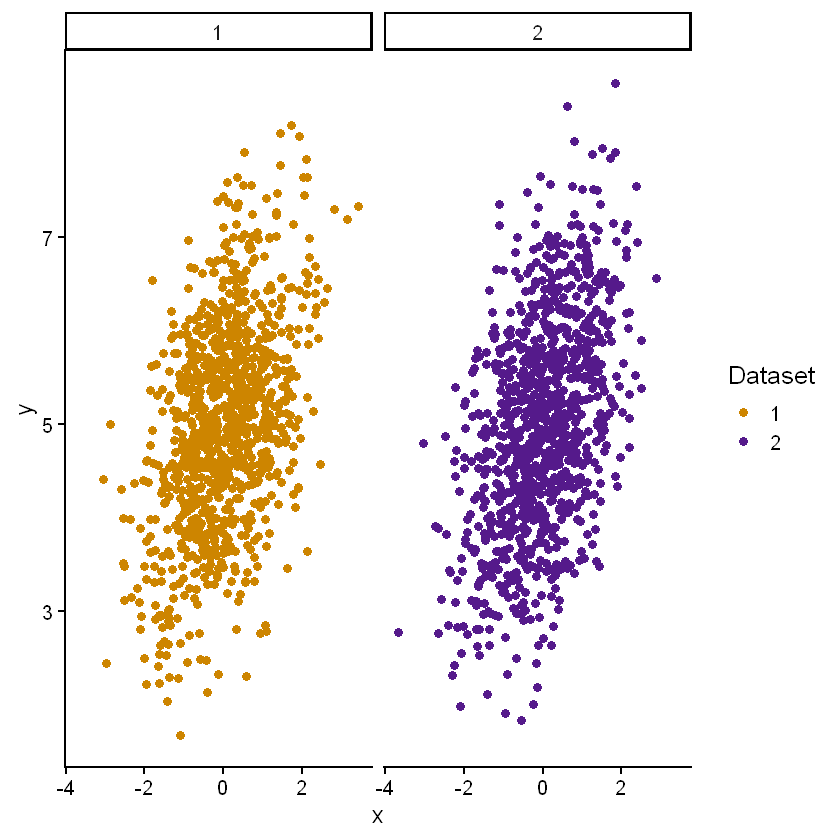

In [5]:
# Plot the simulated relationships

ggplot(combined_dataset) +
  geom_point(aes(x = x, y = y, colour = dataset)) +
  scale_colour_manual(name = "Dataset",
                      values = c("orange3", "purple4")) +
  theme_classic(base_size = 15) +
  facet_wrap(vars(dataset))

### Fitting the models

We now fit the models in `brms`. The specific code will necessarily change with the models used, but the overall idea of setting up data and running the model is the same no matter what approach is used.

#### 1 - Fit a linear model to each dataset and combined data

We assume that we don't know that the observation process is the same in both cases. In the first two models, the standard deviation is estimated as one parameter and therefore not included in the model formula. For the combined model, we need a slightly different model formula to get an estimate of the standard deviation for each dataset. We therefore include an effect of dataset on `sigma`, which is the standard deviation of the response variable `y`.

The model formulation looks like this:

$$
\begin{aligned}
y_i &\sim \mathrm{Normal}(\mu_i, \sigma_d) \\
\mu_i &= \alpha + \beta_{a} x_{a, i} \\
\alpha &\sim \mathrm{Student\:T}(3, 5, 2.5) \\
\beta &\sim \mathrm{Uniform}(-100, 100) \\
\sigma_d &\sim \mathrm{Student\:T}(3, 5, 2.5) \\
\end{aligned}
$$ {#eq-example1}

where $y_i$ is the $i$th value of the response variable, $\mu_i$ is the $i$th mean of the response distribution, $\alpha$ represents the intercept term, $\beta_a$ is the coefficient of the predictor variable $x_a$, and $\sigma_d$ is the standard deviation for the $d$th dataset. Note that the priors shown are the default ones provided by `brms` and have not been changed for the purposes of this document.

In [6]:
# Fit model
## Model 1
form_1 <- bf(y ~ x) #specify model formula

m1 <- brm( #run the model
  formula = form_1, #feed in the model formula
  data = dataset_1, #supply the data
  iter = 2000, #number of MCMC iterations
  warmup = 1000, #number of MCMC iterations to be discarded
  chains = 4, #number of MCMC chains
  cores = 4, #number of computer cores to use to run the chains
  backend = "cmdstanr", #decide which stan/R interface to use
  refresh = 0, #silence progress (for document purposes)
  silent = 2 #silence output (for document purposes)
)

summary(m1) #summarise model output

## Model 2

m2 <- brm(
  formula = form_1, #can use the same formula as variable names match
  data = dataset_2, 
  iter = 2000, 
  warmup = 1000, 
  chains = 4,
  cores = 4, 
  backend = "cmdstanr", 
  refresh = 0, 
  silent = 2
)

summary(m2)

## Combined Model
form_c <- bf(
  y ~ x, 
  sigma ~ dataset # accounts for possible different noise across datasets
)

mc <- brm(
  formula = form_c, 
  data = combined_dataset, 
  iter = 2000, 
  warmup = 1000, 
  chains = 4,
  cores = 4, 
  backend = "cmdstanr", 
  refresh = 0, 
  silent = 2
)

summary(mc)

Loading required namespace: rstan



 Family: gaussian 
  Links: mu = identity 
Formula: y ~ x 
   Data: dataset_1 (Number of observations: 1000) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept     4.98      0.03     4.92     5.05 1.00     4320     2905
x             0.48      0.03     0.42     0.55 1.00     4125     3065

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     0.97      0.02     0.93     1.01 1.00     4737     3118

Draws were sampled using sample(hmc). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

 Family: gaussian 
  Links: mu = identity 
Formula: y ~ x 
   Data: dataset_2 (Number of observations: 1000) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept     5.00      0.03     4.94     5.06 1.00     4507     3044
x             0.52      0.03     0.46     0.58 1.00     4499     3248

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     1.00      0.02     0.96     1.05 1.00     4478     3058

Draws were sampled using sample(hmc). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

 Family: gaussian 
  Links: mu = identity; sigma = log 
Formula: y ~ x 
         sigma ~ dataset
   Data: combined_dataset (Number of observations: 2000) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
                Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept           4.99      0.02     4.95     5.04 1.00     4482     2970
sigma_Intercept    -0.03      0.02    -0.08     0.01 1.00     4437     3059
x                   0.50      0.02     0.46     0.54 1.00     3955     2836
sigma_dataset2      0.04      0.03    -0.02     0.10 1.00     4798     2869

Draws were sampled using sample(hmc). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).


With these models run, we can move on to assessing our models relative to each other. In a more realistic situation, we would spend more time checking the models individually. For more information see, for example: @gabry_visualization_2019 or [this tutorial](https://n-kall.github.io/stancon2026).

### In-sample model predictive performance


Estimating in-sample posterior predictive accuracy is key when assessing the overall fit of a model. See [box 3](box3) for details. In R we can do this for each of our models as follows:

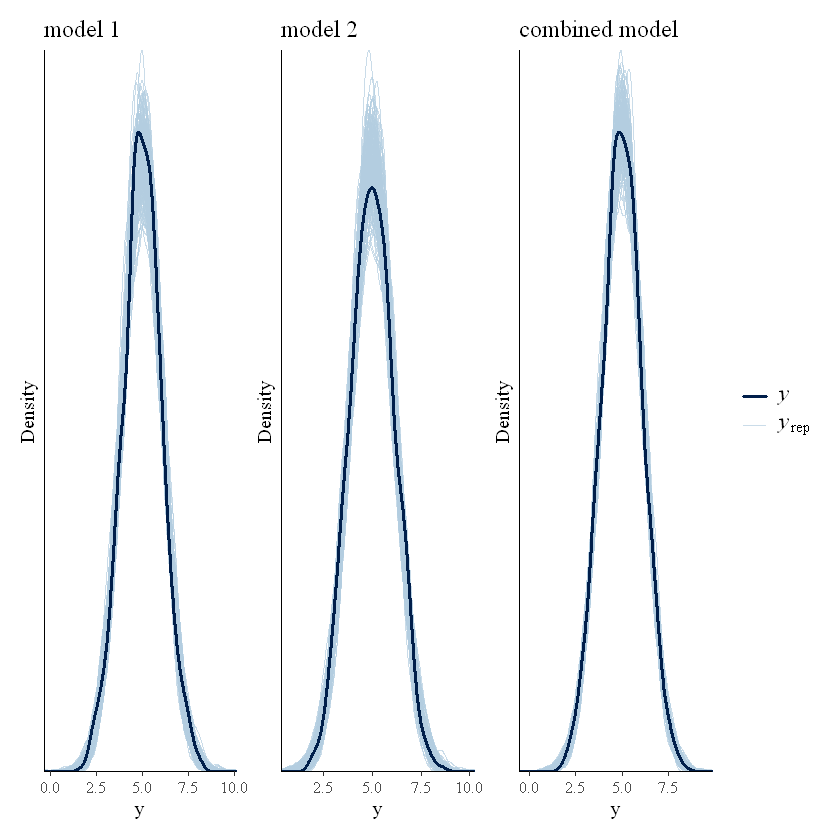

In [7]:
# Compare posterior draws to the dataset
(bayesplot::pp_check(m1, ndraws = 200) + ggtitle("model 1") + scale_x_continuous(name = "y") + 
  scale_y_continuous(name = "Density")) +
  
  (bayesplot::pp_check(m2, ndraws = 200) + ggtitle("model 2") + scale_x_continuous(name = "y") + 
  scale_y_continuous(name = "Density")) +
  
  (bayesplot::pp_check(mc, ndraws = 200) + ggtitle("combined model") + scale_x_continuous(name = "y") + 
  scale_y_continuous(name = "Density")) +
  
  plot_layout(guides = "collect")

In these figures, the black line shows the density of the observed data and the blue lines show the densities of 200 simulated datasets drawn from the posterior predictive distribution. A good fit would be indicated when the black observed density line lies within the range of the blue simulated data lines. One way to think about and interpret these graphs is to ask the question, "if the black line were blue, would I be able to notice it?". If the answer is no, that means the data being predicted by the model is similar to the data that has been observed. If the answer is yes, that means there is some discrepancy between what the model thinks the data should look like and what the data actually look like.

>### Box 3: In-sample posterior predictive performance
>Predictive datasets can be generated from models using parameter estimates. This is, in essence, the answer to the question “what does my model think my data should look like?”. Agreement or mismatch between this and the observed data can be used to determine how well the model is capturing the phenomenon of interest.For a response variable $y_1, ..., y_n$ of independent observations, with $n$ being the total number of observations, we can fit a posterior predictive distribution to each data point and assess how well the data ($\theta$) fit the model parameters i.e. $p(y|\theta)=\prod_{i=1}^{n}p(y_i|\theta)$. This is known as the model likelihood. This is often used as $\mathrm{log}(p(y|\theta))$, (often called the log-likelihood) to make the numerical computation more stable.Suppose we have a prior distribution on model parameters given as $p(\theta)$, we can now use this, our data, and Bayesian updating to obtain a posterior distribution of model parameters $p(\theta|y) = p(y|\theta)p(\theta)$. This posterior distribution is useful as we can obtain a posterior predictive distribution of the response given as $\tilde{y}$.Mathematically this is represented as $p(\tilde{y}|y)=\int p(\tilde{y}_i|\theta)p(\theta|y)d\theta$. In $p(\tilde{y}|y)$ we now have replicated the data generating process for our data $y$ from model parameters $\theta$, with a distribution of predicted response values $\tilde{y}$ for each actual row of response data $y_i$.

#### Extracting pointwise predictive density

To calculate $\mathrm{ELPD_{LOO}}$, we can use the `loo` function (from the `loo` package) to calculate the LOO statistics for:

- model 1

- the combined model's performance on dataset 1

- model 2

- the combined model's performance on dataset 2.

In [8]:
# looic for models 1 and 2
loo_dataset_1 <- loo::loo(m1)
loo_dataset_2 <- loo::loo(m2)

# looic for combined model 
# (currently across all combined data, will be subsetted afterwards)
loo_combined_dataset <- loo::loo(mc)

We can access the $\mathrm{ELPD_{LOO}}$ by calling the `"elpd_loo"` column from the `pointwise` object within the output of the `loo` function, as below.

In [9]:
## subset the combined model's pointwise elpd into the two datasets
loo_combined_dataset_dataset_1 <- loo_combined_dataset$pointwise[combined_dataset$dataset == "1", "elpd_loo"]
loo_combined_dataset_dataset_2 <- loo_combined_dataset$pointwise[combined_dataset$dataset == "2", "elpd_loo"]

## create the pointwise list for model 1
elpd_point_dataset_1 <- cbind(
  loo_dataset_1$pointwise[, "elpd_loo"], 
  loo_combined_dataset_dataset_1)

## create the pointwise list for model 2
elpd_point_dataset_2 <- cbind(
  loo_dataset_2$pointwise[, "elpd_loo"], 
  loo_combined_dataset_dataset_2)

#### Calculating the weights


Pseudo-Bayesian Model Averaging (Pseudo-BMA; @yao_using_2018) can be performed using the [`pseudobma_weights`](https://mc-stan.org/loo/reference/loo_model_weights.html) function from the `loo` package. This converts $\mathrm{ELPD_{LOO}}$ into relative weights which sum to one. See [box 2](box2) for details.

If a model is assigned a weight close to 1, it suggests that model is expected to make better out-of-sample predictions than the alternative (which, due to the nature of the weights summing to 1, will have been assigned a weight close to 0). Weights near 0.5 across two models suggest the models have similar out-of-sample predictive performance.

In [10]:
# calculating the model weighting for each model for dataset 1
pbma_wts_dataset_1 <- loo::pseudobma_weights(elpd_point_dataset_1)
names(pbma_wts_dataset_1) <- c("model 1", "combined model") # name the models correctly
round(pbma_wts_dataset_1, 3) # print the model weights

## calculating the model weighting for each model for dataset 2
pbma_wts_dataset_2 <- loo::pseudobma_weights(elpd_point_dataset_2)
names(pbma_wts_dataset_2) <- c("model 2", "combined model")
round(pbma_wts_dataset_2, 3)

Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 1        0.324 
combined model 0.676 

Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 2        0.312 
combined model 0.688 

For both datasets we see that the combined model is preferred to (i.e. has higher weight than) the single model, as it has better out-of-sample predictive performance.

In this example, the datasets were generated from the same latent state process and therefore both provide agreeing information about this shared latent state process. Therefore, a model that has seen both datasets will have reduced uncertainty in its parameters, leading to better predictive performance than the models that were trained on only one of the datasets. Therefore, the combined model will be assigned a higher weight than the individual models. In this case we would favour the use of the combined model.


## Example 2 (linear regression with multiple predictors) {#example-2-linear-regression-with-multiple-predictors}


In this second example below, we will simulate data that are sampling from the same state process but with different observation processes. We imagine that dataset 1 has less noise in the observation process but a smaller sample size than dataset 2, which we imagine to have a noisier observation process but a larger sample size. We add a second predictor (`xb`), which is categorical. We simulate the two datasets to have imperfect overlap in the values of this second predictor, so that each dataset will contain some values of this predictor that are shared and some will be unique to each dataset. We add this to demonstrate that this does not impact the protocol we outline.

In [11]:
# simulation parameters
n1 <- 1e3 # sample size for dataset 1
n2 <- 1e4 # sample size for dataset 2

# state process parameters
xa1 <- rnorm(n1, 0, 1) # xa is a continuous, scaled variable
xa2 <- rnorm(n2, 0, 1) # xa is a continuous, scaled variable
beta_xa1 <- beta_xa2 <- 2 # effect size of xa of y

xb1 <- sample(letters[1:5], n1, replace = T) # xb is a categorical variable
xb2 <- sample(letters[3:7], n2, replace = T) # xb is a categorical variable
beta_xb <- c(0, 0.5, 1, 1.5, 2, -1, -2) # effect size of each category of xb on y

# observation process parameters
sd1 <- 1
sd2 <- 5
set.seed(1312)

# simulate dataset 1 (low noise)
mu1 <- 0.5 + beta_xa1*xa1 + model.matrix(~ -1 + xb1) %*% beta_xb[1:5] # the xa and xb dependent mean of y
# note that the second part of the above applies the effect of the xb category by creating dummy variables
# and multiplying each by the respective effect size in beta_xb

y1 <- rnorm(n1, mu1, sd1) # y is a continuous response dependent on xa and xb with some 
                        #normally-distributed noise

dataset_1 <- data.frame( #bind all dataset 1 variables into dataframe
    xa = xa1, 
    xb = xb1, 
    y = y1, 
    dataset = "1"
)

# simulate dataset 2 (more noise)
mu2 <- 0.5 + beta_xa2*xa2 + model.matrix(~ -1 + xb2) %*% beta_xb[3:7] # the xa and xb dependent mean of y

y2 <- rnorm(n2, mu2, sd2)# y is a continuous response dependent on xa and xb with some 
                        #normally-distributed noise

dataset_2 <- data.frame( #bind all dataset 2 variables into dataframe
    xa = xa2, 
    xb = xb2, 
    y = y2, 
    dataset = "2"
)

# combine the datasets

combined_dataset <- rbind(dataset_1, dataset_2) # bind datasets 1 and 2 together

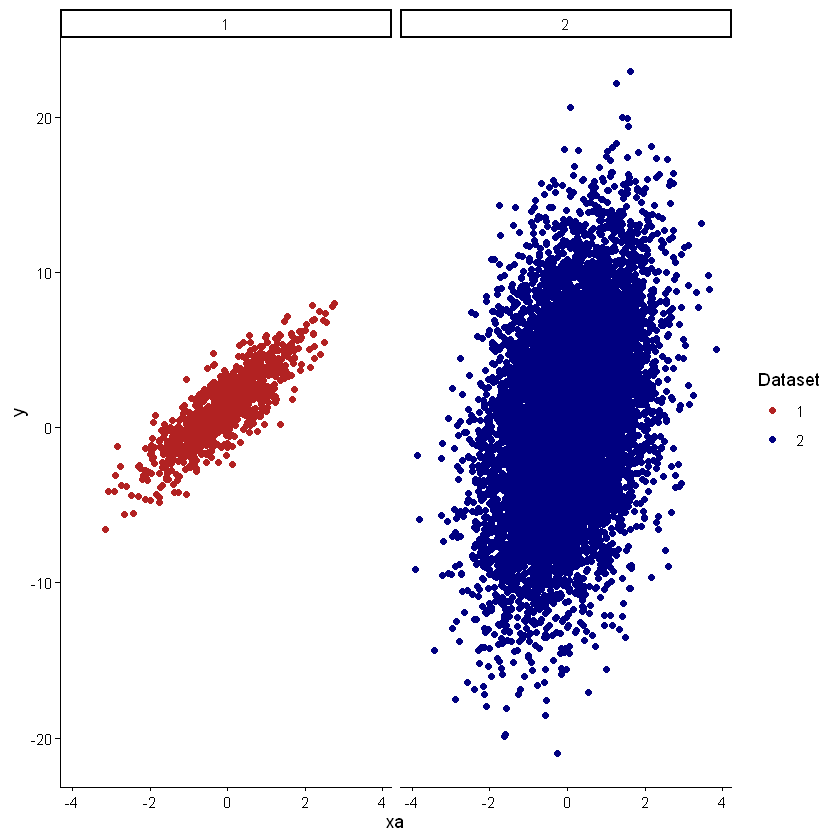

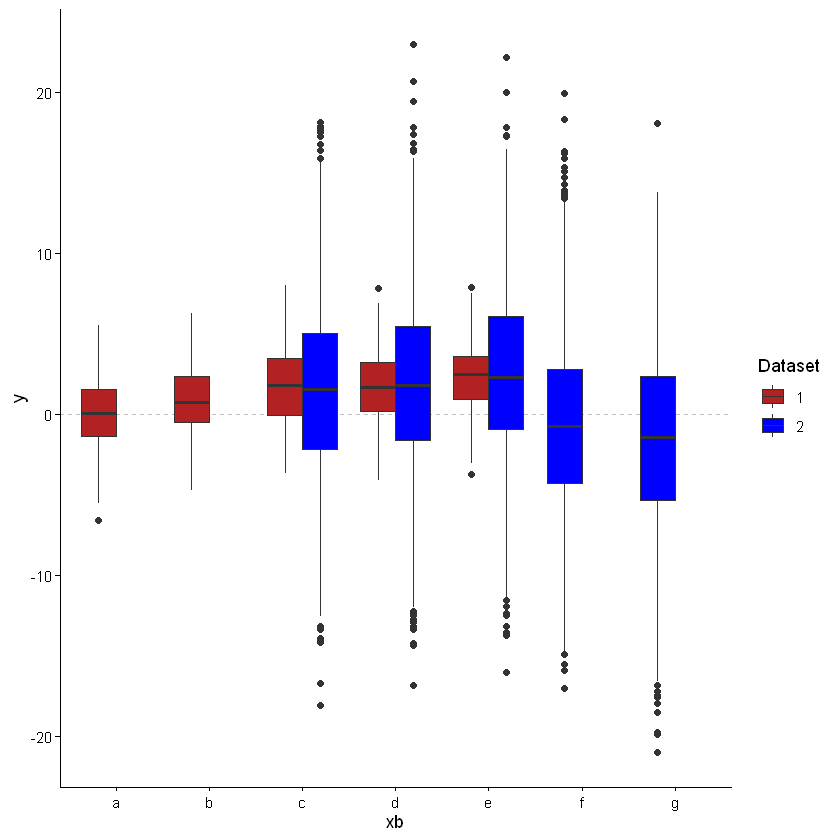

In [12]:
#visualise effect of xa on y across both datasets
ggplot(data = combined_dataset, aes(x = xa, y = y, colour = dataset)) + 
    geom_point() + 
    scale_colour_manual(name = "Dataset", values = c("firebrick", "navy")) + 
    theme_classic() + 
    facet_wrap(vars(dataset))

#visualise effect of xb on y across both datasets

ggplot(data = combined_dataset, aes(x = xb, y = y, fill = dataset)) + 
	geom_hline(yintercept = 0, linetype = "dashed", colour = "grey") +
    geom_boxplot(position = position_dodge(width = 0.75, preserve = "single")) + 
	scale_x_discrete(drop = FALSE) +
    scale_fill_manual(name = "Dataset", values = c("firebrick", "blue")) + 
    theme_classic()  

We have now simulated two datasets. We have two predictor variables; one continuous `xa`, and one categorical `xb`. We do not have perfect matching of the values of `xb` across the two datasets, but this does not present a problem to our model averaging methodology because we are only ever comparing model performance within datasets. Dataset 1 is smaller and has less noise around the response variable than dataset 2, which is larger but has more noise around the response variable. We have also combined these two datasets into one object and included a column that denotes which dataset an observation came from.

We can now model dataset 1 and dataset 2 individually (with two separate models) and model the combined dataset, taking into account the possible difference in noise/variation that the different observation processes in each dataset may introduce. Note that, for the purposes of brevity, the full code to run these models will not be shown here. However, the process is exactly the same as the previous example, but the model formula is now `form_1 <- bf(y ~ xa + xb)` for the individual models and `form_c <- bf(y ~ xa + xb, sigma ~ dataset)` for the combined model.

The new model formulation looks like this:

$$
\begin{aligned}
y_i &\sim \mathrm{Normal}(\mu_i, \sigma_d) \\
\mu_i &= \alpha + \beta_{a} x_{a, i} + \beta_{b} x_{b, i}\\
\alpha &\sim \mathrm{Student\:T}(3, 5, 2.5) \\
\beta &\sim \mathrm{Uniform}(-100, 100) \\
\sigma_d &\sim \mathrm{Student\:T}(3, 5, 2.5)
\end{aligned}
$$ {#eq-example2}

In [13]:
# run model 1
form_1 <- bf(y ~ xa + xb) # model formula
m1 <- brm( #fit the model with brms
    formula = form_1, 
    data = dataset_1, 
    iter = 2000, # total iterations
    warmup = 1000, # number to be discarded as warmup
    chains = 4, 
    cores = 4, # number of cores (4 cores and 4 chains = 1 chain per core)
    backend = "cmdstanr", # optional argument to change backend (can also be "rstan"), 
    refresh = 0, # silence model run info (for document purposes only)
    silent = 2 # silence model run (for document purposes only)
)

# summary(m1) # inspect model output
# bayesplot::mcmc_trace(m1) # inspect trace plot (not run here)

# run model 2
m2 <- brm( #fit the model with brms
    formula = form_1, # can use the same model formula as before as variable names match
    data = dataset_2, 
    iter = 2000, # total iterations
    warmup = 1000, # number to be discarded as warmup
    chains = 4, 
    cores = 4, # number of cores (4 cores and 4 chains = 1 chain per core)
    backend = "cmdstanr", # optional argument to change backend (can also be "rstan"), 
    refresh = 0, # silence model run info (for document purposes only)
    silent = 2 # silence model run (for document purposes only)
)


# summary(m2) # inspect model output
# bayesplot::mcmc_trace(m2) # inspect trace plot (not run here)

# run combined model
form_c <- bf( 
    y ~ xa + xb, 
    sigma ~ dataset # this will account for possible differences in noise across datasets
)

mc <- brm( #fit the model with brms
    formula = form_c,
    data = combined_dataset, 
    iter = 2000, # total iterations
    warmup = 1000, # number to be discarded as warmup
    chains = 4, 
    cores = 4, # number of cores (4 cores and 4 chains = 1 chain per core)
    backend = "cmdstanr", # optional argument to change backend (can also be "rstan"), 
    refresh = 0, # silence model run info (for document purposes only)
    silent = 2 # silence model run (for document purposes only)
)

Having run the models, we can now use the `loo` function to extract ELPD for each row of data for each model, and use these to calculate model weights.

In [14]:
# extract pointwise elpd for each dataset and model
loo_1 <- loo::loo(m1)
loo_2 <- loo::loo(m2, cores = 4) # optional argument to parallelise because of larger data
loo_c <- loo::loo(mc, cores = 4)

elpd_1 <- cbind( # bind the pointwise elpd from model 1 and combined model for dataset 1
    loo_1$pointwise[, "elpd_loo"], 
    loo_c$pointwise[combined_dataset$dataset == "1", "elpd_loo"]
)

elpd_2 <- cbind( # bind the pointwise elpd from model 2 and combined model for dataset 2
    loo_2$pointwise[, "elpd_loo"], 
    loo_c$pointwise[combined_dataset$dataset == "2", "elpd_loo"]
)

weights_1 <- loo::pseudobma_weights(elpd_1) # calculate PBMA+ weights for dataset 1
names(weights_1) <- c("model 1", "combined model") # change names to match model names
round(weights_1, 3) # display model weights

weights_2 <- loo::pseudobma_weights(elpd_2) # calculate PBMA+ weights for dataset 2
names(weights_2) <- c("model 2", "combined model") # change names to match model names
round(weights_2, 3) # display model weights

Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 1        0.429 
combined model 0.571 

Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 2        0.376 
combined model 0.624 

In the above example, we can see that, again, the PBMA+ weighting procedure recommends modelling the data together despite dataset 2 being larger and noisier than dataset 1. This is, again, due to the fact that the combined model has less uncertainty around the parameters shared between the two datasets due to the larger sample size of the combined dataset (i.e. the parameters associated with the state process, which is assumed to be the same across datasets 1 and 2; the intercept term and the effect of both the continuous and categorical predictors in this example). This in turn allows the combined model to disentangle the state and observation processes with more certainty and therefore predict the datasets more closely than the individual models (which have less certainty about how do divide variation into noise from the observation process and patterns in the state process).

## Example 3 (disagreeing datasets)

Continuing from example 2, we now simulate 2 new datasets. However, these datasets <b><i>do not agree</i></b> on the state process underlying the data. Both predictors have a positive effect in dataset 1 and have a negative effect in dataset 2. As above, we can model dataset 1 and dataset 2 individually, and model the combined dataset. Again, for the purposes of brevity, the full code to run these models will not be shown here. However, the process is exactly the same as the [previous example](#example-2-linear-regression-with-multiple-predictors). The model formulation is also the same as that provided in @eq-example2.

In [15]:
set.seed(1066)

# simulate dataset 1 (low noise)
n1 <- 1e3 # sample size for dataset 1
xa1 <- rnorm(n1, 0, 1) # xa is a continuous, scaled variable
beta_xa1 <- 2 # effect size of xa on y

xb1 <- sample(letters[1:5], n1, replace = T) # xb is a categorical variable
beta_xb1 <- c(0, 0.5, 1, 1.5, 2, 2.5, 3) # effect size of each category of xb on y

mu1 <- 0.5 + beta_xa1*xa1 + model.matrix(~ -1 + xb1) %*% beta_xb1[1:5] # the xa and xb dependent mean of y
# note that the second part of the above applies the effect of the xb category by creating dummy variables
#and multiplying each by the respective effect size in beta_xb1

y1 <- rnorm(n1, mu1, 1) # y is a continuous response dependent on xa and xb with some 
                        #normally-distributed noise

dataset_1 <- data.frame( #bind all dataset 1 variables into dataframe
    xa = xa1, 
    xb = xb1, 
    y = y1, 
    dataset = "1"
)

# simulate dataset 1 (more noise)
n2 <- 1e4 # sample size for dataset 2
xa2 <- rnorm(n2, 0, 1) # xa is a continuous, scaled variable
beta_xa2 <- -2 # effect size of xa of y (flipped sign of beta_xa1)

xb2 <- sample(letters[3:7], n2, replace = T) # xb is a categorical variable
beta_xb2 <- c(0, -0.5, -1, -1.5, -2, -2.5, -3)

mu2 <- 0.5 + beta_xa2*xa2 + model.matrix(~ -1 + xb2) %*% beta_xb2[3:7] # the xa and xb dependent mean of y

y2 <- rnorm(n2, mu2, 5)# y is a continuous response dependent on xa and xb with some 
                        #normally-distributed noise

dataset_2 <- data.frame( #bind all dataset 2 variables into dataframe
    xa = xa2, 
    xb = xb2, 
    y = y2, 
    dataset = "2"
)

# combine the datasets

combined_dataset <- rbind(dataset_1, dataset_2) # bind datasets 1 and 2 together

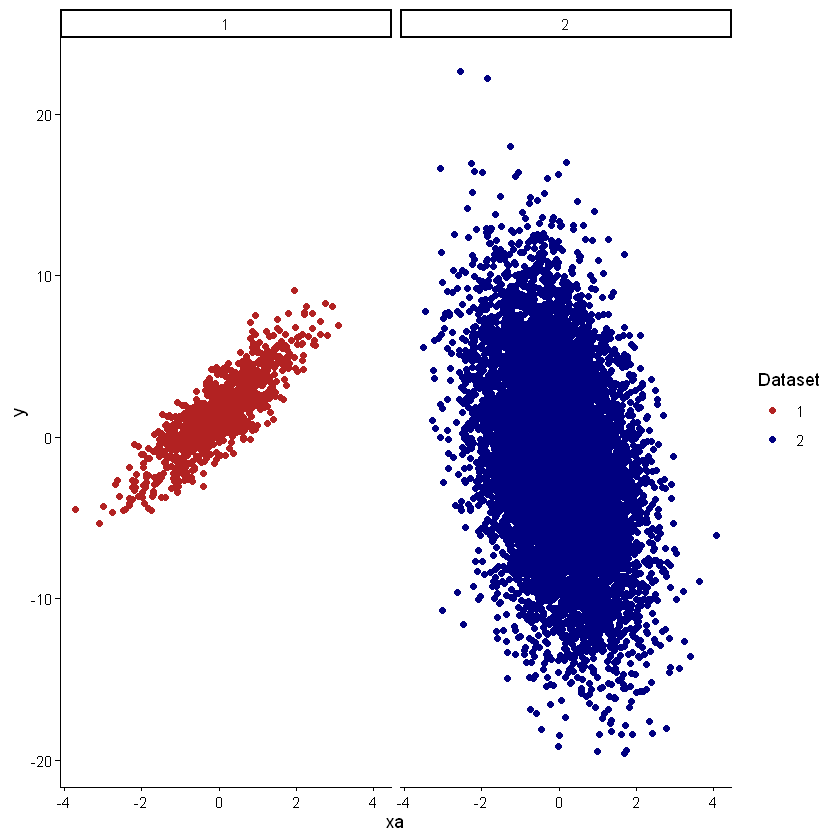

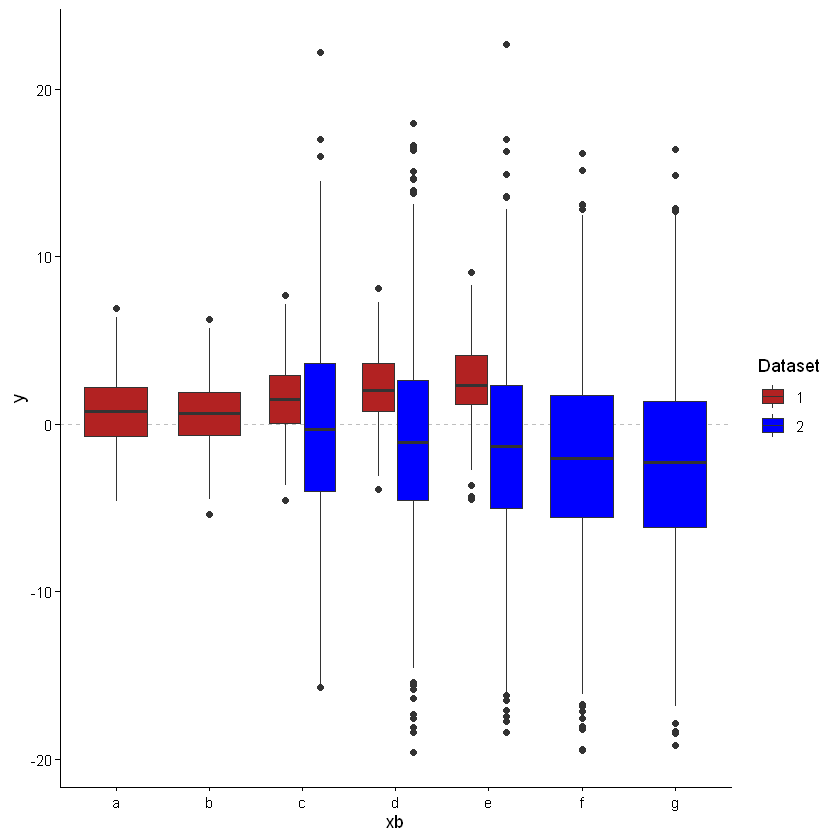

In [16]:
#visualise effect of xa on y across both datasets
ggplot(data = combined_dataset, aes(x = xa, y = y, colour = dataset)) + 
    geom_point() + 
    scale_colour_manual(name = "Dataset", values = c("firebrick", "navy")) + 
    theme_classic() + 
    facet_wrap(vars(dataset))

#visualise effect of xb on y across both datasets
ggplot(data = combined_dataset, aes(x = xb, y = y, fill = dataset)) + 
    geom_hline(aes(yintercept = 0), linetype = "dashed", colour = "grey") + 
    geom_boxplot() + 
    scale_fill_manual(name = "Dataset", values = c("firebrick", "blue")) + 
    theme_classic()
    # facet_wrap(vars(dataset))

In [17]:
# run model 1
form_1 <- bf(y ~ xa + xb) # model formula
m1 <- brm( #fit the model with brms
    formula = form_1, 
    data = dataset_1, 
    iter = 2000, # total iterations
    warmup = 1000, # number to be discarded as warmup
    chains = 4, 
    cores = 4, # number of cores (4 cores and 4 chains = 1 chain per core)
    backend = "cmdstanr", # optional argument to change backend (can also be "rstan"), 
    refresh = 0, # silence model run info (for document purposes only)
    silent = 2 # silence model run (for document purposes only)
)

# summary(m1) # inspect model output
# bayesplot::mcmc_trace(m1) # inspect trace plot (not run here)

# run model 2
m2 <- brm( #fit the model with brms
    formula = form_1, # can use the same model formula as before as variable names match
    data = dataset_2, 
    iter = 2000, # total iterations
    warmup = 1000, # number to be discarded as warmup
    chains = 4, 
    cores = 4, # number of cores (4 cores and 4 chains = 1 chain per core)
    backend = "cmdstanr", # optional argument to change backend (can also be "rstan"), 
    refresh = 0, # silence model run info (for document purposes only)
    silent = 2 # silence model run (for document purposes only)
)


# summary(m2) # inspect model output
# bayesplot::mcmc_trace(m2) # inspect trace plot (not run here)

# run combined model
form_c <- bf( 
    y ~ xa + xb, 
    sigma ~ dataset # this will account for possible differences in noise across datasets
)

mc <- brm( #fit the model with brms
    formula = form_c,
    data = combined_dataset, 
    iter = 2000, # total iterations
    warmup = 1000, # number to be discarded as warmup
    chains = 4, 
    cores = 4, # number of cores (4 cores and 4 chains = 1 chain per core)
    backend = "cmdstanr", # optional argument to change backend (can also be "rstan"), 
    refresh = 0, # silence model run info (for document purposes only)
    silent = 2 # silence model run (for document purposes only)
)

In [18]:
# extract pointwise elpd for each dataset and model
loo_1 <- loo::loo(m1)
loo_2 <- loo::loo(m2, cores = 4) # optional argument to parallelise because of larger data
loo_c <- loo::loo(mc, cores = 4)

elpd_1 <- cbind( # bind the pointwise elpd from model 1 and combined model for dataset 1
    loo_1$pointwise[, "elpd_loo"], 
    loo_c$pointwise[combined_dataset$dataset == "1", "elpd_loo"]
)

elpd_2 <- cbind( # bind the pointwise elpd from model 2 and combined model for dataset 2
    loo_2$pointwise[, "elpd_loo"], 
    loo_c$pointwise[combined_dataset$dataset == "2", "elpd_loo"]
)

weights_1 <- loo::pseudobma_weights(elpd_1) # calculate PBMA+ weights for dataset 1
names(weights_1) <- c("model 1", "combined model") # change names to match model names
round(weights_1, 3) # display model weights

weights_2 <- loo::pseudobma_weights(elpd_2) # calculate PBMA+ weights for dataset 2
names(weights_2) <- c("model 2", "combined model") # change names to match model names
round(weights_2, 3) # display model weights


Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 1        1.000 
combined model 0.000 

Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 2        1.000 
combined model 0.000 

In this example, we can see that all weight is given to the individual models and none to the combined model. This is because the datasets do not contain agreeing information on the state process (they are measurements of fundamentally different processes). Therefore, despite the fact that one of the datasets is an order of magnitude larger than the other, the combined model cannot predict either dataset better than the individual models, and so all weight is given to the individual models. Therefore, the recommended way to proceed would be to model each dataset individually, and be cautious in any inference that assumes both datasets measure the same state process.

## Example 4 (occupancy model)

This example shows how the model averaging procedure would work with a more complex model - an occupancy model. Here we simulate a dataset consisting of 100 sites, each being visited 4 times a year (assuming no change in occupancy within each year) for 10 years. We assume that the probability of occupancy across sites is the same, but decreases across years. We also assume that each dataset has its own probability of detecting occupancy, and this detection probability remains the same across years. We also assume perfect overlap in which sites are visited between the two datasets.

In [19]:
set.seed(2077)

# set data simulation variables
n_datasets <- 2
n_sites <- 100
n_visits <- 4
n_years <- 10 #number of years each site was visited (this simulation assumes no missing data per site across the years)

# define probability of occupancy
aa <- logit(0.9) #high probability of occupancy in first year
b_year <- -0.5 #how much p_occ decreases by every year (on logit scale)

# define probability of detection
round(p_det <- runif(n_datasets, 0, 1), 2) #probability of detection

# initialise dataframe and simulate latent state and observed data
# note: we're assuming closure across visits within a year, occupancy can change across years, and detection probability 
# is constant across years but different across the datasets

df <- expand.grid(1:n_datasets, 1:n_years, 1:n_sites, 1:n_visits) %>% #create a dataframe with each unique combination of these 
  data.frame() %>%
  rename( # change column names
    dataset  = Var1, 
    year = Var2, 
    site = Var3, 
    visit = Var4
  ) %>%
  group_by(year, site) %>% #assign latent occupancy status for each site for each year
  mutate(
    z = rbinom(size = 1, n = 1, prob = inv_logit(aa + (b_year * year)))
  ) %>%
  ungroup() %>%
  mutate(
    detection = rbinom(size = 1, n = n(), prob = p_det[dataset]), #would occupancy have been detected? (1 = detected, 0 = not detected),
    value = if_else(z == 1 & detection == 1, 1, 0) #assign observed occupancy status
  )

[1] 0.64 0.37

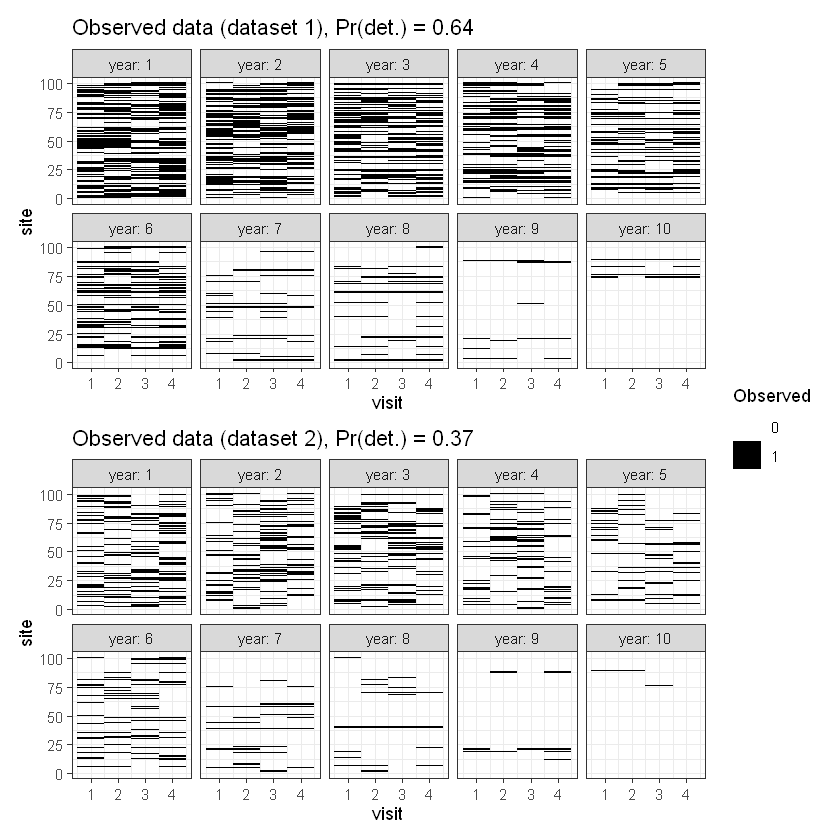

In [20]:
#plot observed occupancy status across the two datasets
p2df1 <- ggplot(data = df %>% filter(dataset == 1)) + 
    geom_tile(aes(x = visit, y = site, fill = factor(value))) + 
    scale_fill_manual(name = "Observed", values = c("transparent", "black")) + 
    theme_bw() + 
    facet_wrap(vars(year), labeller = "label_both", nrow = 2) + 
    ggtitle(paste0("Observed data (dataset 1), Pr(det.) = ", round(p_det[1], 2)))

p2df2 <- ggplot(data = df %>% filter(dataset == 2)) + 
    geom_tile(aes(x = visit, y = site, fill = factor(value))) + 
    scale_fill_manual(name = "Observed", values = c("transparent", "black")) + 
    theme_bw() + 
    facet_wrap(vars(year), labeller = "label_both", nrow = 2) + 
    ggtitle(paste0("Observed data (dataset 2), Pr(det.) = ", round(p_det[2], 2)))

p2df1 / p2df2 + 
    plot_layout(guides = "collect")

The occupancy model used in this example is formulated as:

$$
\begin{aligned}
    y_{d, t, j, i} &\sim \mathrm{Bernoulli}(z_{t, j} \times p_d) \\
    z_{t, j} &\sim \mathrm{Bernoulli}(\psi_t) \\
    \mathrm{logit}(\psi_t) &= \alpha + \beta t \\
    \alpha &\sim \mathrm{Normal}(0, 0.75) \\
    \beta &\sim \mathrm{Normal}(0, 0.4) \\
    p_d &\sim  \mathrm{Normal}(0, 1.2) \\
\end{aligned}
$$ {#eq-occ-model1}

where $y_{d, t, j, i}$ is the observed occupancy state in dataset $d$ in year $t$ at site $j$ on visit $i$. $z_{t, j}$ is the latent occupancy state (whether the site was actually occupied) in year $y$ at site $j$. $\psi_t$ is the probability of occupancy for year $t$ (which is shared across all sites). $\alpha$ and $\beta$ represent the intercept and change in occupancy probability across years (respectively). $p_d$ represents the probability of detecting occupancy in dataset $d$.

As in previous examples, we can model these datasets individually and together, and extract the PBMA+ weights. We use an occupancy model written in BUGS and run using JAGS in this example in order to demonstrate the slight changes in methods needed extract the relevant information needed.


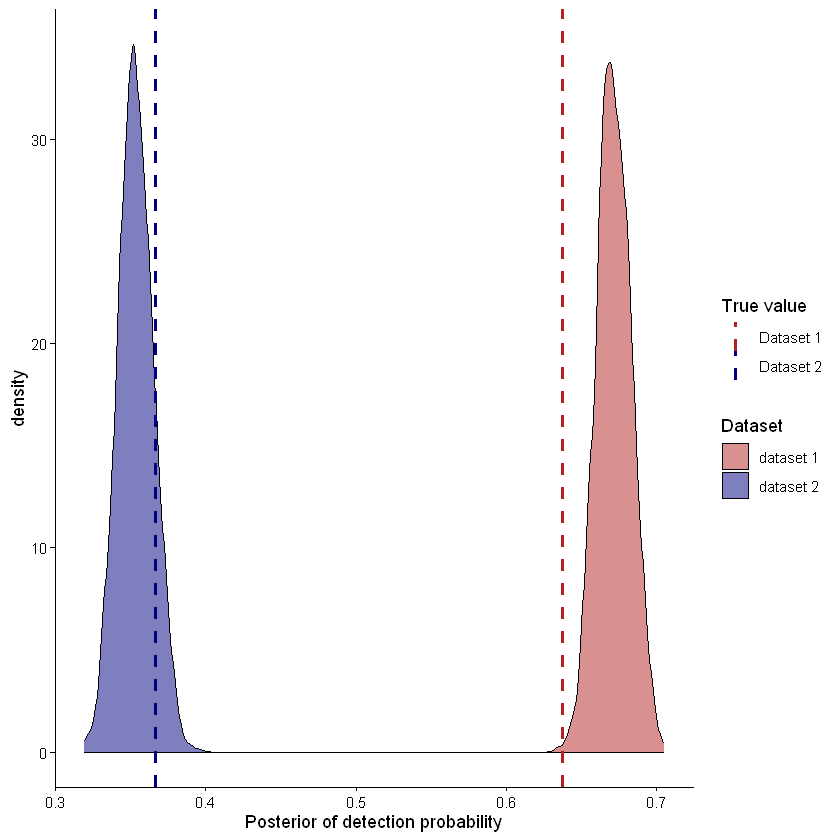

In [22]:
#load required libraries
require(jagsUI)

#subset to each dataset
df1 <- filter(df, dataset == 1)

#create empty array to fill with observed data
y1 <- array(
    dim = c(length(unique(df1$dataset)), max(df1$year), max(df1$site), max(df1$visit))
)

#fill array of observations
for(i in 1:nrow(df1)) {
    y1[df1$dataset[i], df1$year[i], df1$site[i], df1$visit[i]] <- df1$value[i]
}

data_list_1 <- list( # create datalist to pass to JAGS model
    n_datasets = dim(y1)[1],
    n_years = dim(y1)[2], 
    n_sites = dim(y1)[3], 
    n_visits = dim(y1)[4], 
    y = y1
)

# calculate initial values for z (latent occupancy state)
z_inits_1 <- apply(y1, c(2, 3), max, na.rm = TRUE) # compute max detection for each year and site
z_inits_1[is.na(z_inits_1) | z_inits_1 == -Inf] <- 1 # if all visits were NA, default to 1 (or 0)

inits_1 <- function() list( #create list of initial values for JAGS model
    z = z_inits_1,
    alpha = 0, 
    beta = 0,
    p = rep(0, length(unique(df1$dataset)))
)

parameters <- c("alpha", "beta", "p", "log_lik") #parameters to be monitored

ni <- 2000;  nb <- 500;  nt <- 4;  nc <- 4  # MCMC settings

samples1 <- jags( #run model
    model.file="jags_occ_model.bugs", 
    data=data_list_1, 
    inits=inits_1, 
    parameters.to.save=parameters, 
    n.iter=ni, 
    n.burnin=nb, 
    n.thin=nt,
    n.chains=nc, 
    parallel = T, 
    verbose = F #silences output (for the purpose of the document)
)

# usual model summaries are not run here as log_lik is a huge object
# jagsUI::traceplot(samples1) #inspect traceplot (not run here)
# samples1$summary #inspect model output (not run here)
# samples1$Rhat #inspect r-hat (not run here)

# extract log-likelihood for each observation
log_lik_1 <- matrix(samples1$sims.list$log_lik, nrow = dim(samples1$sims.list$log_lik)[1])


# subset data to dataset 2
df2 <- filter(df, dataset == 2)

y2 <- array(
    dim = c(length(unique(df2$dataset)), max(df2$year), max(df2$site), max(df2$visit))
)

for(i in 1:nrow(df2)) {
    y2[df2$dataset[i] - 1, df2$year[i], df2$site[i], df2$visit[i]] <- df2$value[i]
}

#create datalist
data_list_2 <- list(
    n_datasets = dim(y2)[1],
    n_years = dim(y2)[2], 
    n_sites = dim(y2)[3], 
    n_visits = dim(y2)[4], 
    y = y2
)

z_inits_2 <- apply(y2, c(2, 3), max, na.rm = TRUE)
z_inits_2[is.na(z_inits_2) | z_inits_2 == -Inf] <- 1

inits_2 <- function() list(
    z = z_inits_2,
    alpha = 0, 
    beta = 0,
    p = rep(0, length(unique(df2$dataset)))
)

samples2 <- jags(
    model.file="jags_occ_model.bugs", 
    data=data_list_2, 
    inits=inits_2, 
    parameters.to.save=parameters, 
    n.iter=ni, 
    n.burnin=nb, 
    n.thin=nt,
    n.chains=nc, 
    parallel = T, 
    verbose = F #silences output (for the purpose of the document)
)

# jagsUI::traceplot(samples2) #not run here
# samples2$summary #not run here
# samples2$Rhat #not run here

# extract log-likelihood for each visit for each site
log_lik_2 <- matrix(samples2$sims.list$log_lik, nrow = dim(samples2$sims.list$log_lik)[1])


# run model on combined data
yc <- array(
    dim = c(length(unique(df$dataset)), max(df$year), max(df$site), max(df$visit))
)

for(i in 1:nrow(df)) {
    yc[df$dataset[i], df$year[i], df$site[i], df$visit[i]] <- df$value[i]
}

#create datalist
data_list_c <- list(
    n_datasets = dim(yc)[1],
    n_years = dim(yc)[2], 
    n_sites = dim(yc)[3], 
    n_visits = dim(yc)[4], 
    y = yc
)

# Define initial values and settings for MCMC
z_inits_c <- apply(yc, c(2, 3), max, na.rm = TRUE)

# If all visits were NA, default to 1 (or 0)
z_inits_c[is.na(z_inits_c) | z_inits_c == -Inf] <- 1

inits_c <- function() list(
    z = z_inits_c,
    alpha = 0, 
    beta = 0,
    p = rep(0, data_list_c$n_datasets)
)

# Run model
samplesc <- jags(
    model.file="jags_occ_model.bugs", 
    data=data_list_c, 
    inits=inits_c, 
    parameters.to.save=parameters, 
    n.iter=ni, 
    n.burnin=nb, 
    n.thin=nt,
    n.chains=nc, 
    parallel = T, 
    verbose = F #silences output (for the purpose of the document)
)

#jagsUI::traceplot(samplesc) #not run here
#samplesc$summary #not run here

# plot posteriors of detection probabilities vs. true values
inv_logit(samplesc$sims.list$p) %>%
  data.frame() %>%
  rename(
    dataset_1 = 1, 
    dataset_2 = 2
  ) %>%
  tidyr::pivot_longer(cols = everything()) %>%
  mutate(name = gsub("_", " ", name)) %>%
  ggplot() + 
    geom_density(aes(x = value, fill = name), alpha = 0.5) + 
    geom_vline(aes(xintercept = p_det[1], colour = "Dataset 1"), linetype = "dashed", linewidth = 1) + 
    geom_vline(aes(xintercept = p_det[2], colour = "Dataset 2"), linetype = "dashed", linewidth = 1) +
    scale_x_continuous(name = "Posterior of detection probability") + 
    scale_fill_manual(name = "Dataset", values = c("firebrick", "navy")) + 
    scale_colour_manual(name = "True value", values = c("firebrick", "navy")) + 
    theme_classic()#look at detection probs

In [23]:
# extract log-likelihood for each visit for each site for each dataset
# note: this step is slightly different from the examples using brms as 
# the log-likelihood matrix needs to manually extracted and reshaped
log_lik_c <- matrix(samplesc$sims.list$log_lik, nrow = dim(samplesc$sims.list$log_lik)[1])

# run loo on log_lik matrices
loo_1 <- loo::loo(log_lik_1, cores = 4)
loo_2 <- loo::loo(log_lik_2, cores = 4)
loo_c <- loo::loo(log_lik_c, cores = 4)

# extract and compare pointwise elpd estimates
elpd_1 <- cbind(
    loo_1$pointwise[, "elpd_loo"], 
    loo_c$pointwise[df$dataset == 1, "elpd_loo"]
)
pbma_wts_1 <- loo::pseudobma_weights(elpd_1)
names(pbma_wts_1) <- c("model 1", "combined model")
round(pbma_wts_1, 3)


elpd_2 <- cbind(
    loo_2$pointwise[, "elpd_loo"], 
    loo_c$pointwise[df$dataset == 2, "elpd_loo"]
)

pbma_wts_2 <- loo::pseudobma_weights(elpd_2)
names(pbma_wts_2) <- c("model 2", "combined model")
round(pbma_wts_2, 3)

Warning message:
"Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
"
Warning message:
"Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
"
Warning message:
"Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
"


Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 1        0.064 
combined model 0.936 

Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 2        0.000 
combined model 1.000 

Like the linear regression examples, the pseudo-BMA weights for the occupancy model exhibits a symmetrical pattern between datasets. The combined model (each with a different probability of detection) received higher weights than either of the individual models, due to the combined model accounting for difference in the observation process between the datasets (i.e. varying detection probability) and having more information to inform the parameters governing the latent state process (which, in this example, is the true site occupancy status).

> ## Box 4: What if we get assymetrical weights across the models?
> It is possible that one could carry out the model weighting procedure and have a result that looks like this:
> ```         
> Method: pseudo-BMA+ with Bayesian bootstrap
> ------
>                weight
> model 1        1.000
> combined model 0.000         
> Method: pseudo-BMA+ with Bayesian bootstrap
> ------
>                weight
> model 2        0.000 
> combined model 1.000
> ```
> where it is suggested that an individual model predicts dataset 1 better (i.e. not combining this dataset with dataset 2), whereas the combined model predicts dataset 2 better; this could happen if the individual model for dataset 2 is a poor fit and has not been able to disentangle the state and observation processes, for example. The way forward is less clear in this situation. Such a result would suggest caution before adopting a single combined model for all inference or prediction. If the goal is optimal out-of-sample prediction, one might consider dataset-specific model selection or model-averaged predictions where dataset 1 relies heavily on model 1 draws, while dataset 2 relies predominantly on the combined model draws. In example 4, the two datasets have perfect overlap in the sites they visit. However, in a situation where dataset 1 and dataset 2 had visits at different sites (possibly with different characteristics), a recommended approach may be to use model 1 to predict for sites exclusively in (or more similar to those in) dataset 1, while using the combined model to predict for sites in (or more similar to those in) dataset 2.

## Example 5 (mixed likelihoods)


Because we are always comparing model performance *within* datasets and across models, we can use this procedure to compare individual models, each of which may have a different likelihood resulting from different response data types, to a mixture model in which both datasets (and therefore data types) are modelled together and both contribute to resolving shared parameters.

We imagine a situation similar to that laid out in example 4, in which a number of sites are visited with the aim of determining a species distribution. However, in this example, we imagine that species abundance has been counted (i.e. the number of individuals detected per site, per visit). We then imagine that one of the datasets (dataset 1) has been collapsed into binary presence/absence data where, if a non-zero count is detected, that site visit is marked as "present" (1). The other dataset (dataset 2) remains as a count of individuals detected. In this example, both datasets are still being generated by the same state process (species abundance), but one of the datasets has been censored.

To simulate this kind of data, we first simulate two sets of abundance data and then censor dataset 1 to presence/absence. Note that we assume a fixed probability of detection across the two datasets, and we assume that latent population size increases across the sampling years.

In [24]:
set.seed(987654321)

#Assumes an area of interest that has some latent population that we want to try and figure out by sampling
n_datasets <- 2
n_sites <- 100
n_visits <- 4
n_years <- 10 #number of years each site was visited (this simulation assumes no missing data per site across the years)

#prob of occupancy
aa <- log(0.1)
b_year <- 0.5 #how much latent population size decreases by every year (on log scale)

#prob of detection
p_det <- 0.75 #fixed detection probability in both datasets

df <- expand.grid(1:n_datasets, 1:n_years, 1:n_sites, 1:n_visits) %>%
    data.frame() %>%
    rename(
        dataset  = Var1, 
        year = Var2, 
        site = Var3, 
        visit = Var4
    ) %>%
    group_by(year, site) %>%
    mutate(
        z = rpois(1, exp(aa + (b_year * year))) #latent population size
    ) %>%
    ungroup() %>%
    mutate(
        obs_n = rbinom(size = z, n = n(), prob = p_det), #observation process
        value = case_when(
            dataset == 1 & obs_n > 0 ~ 1, #censor the values from dataset 1
            dataset == 2 ~ obs_n, 
            TRUE ~ 0
        )
    )

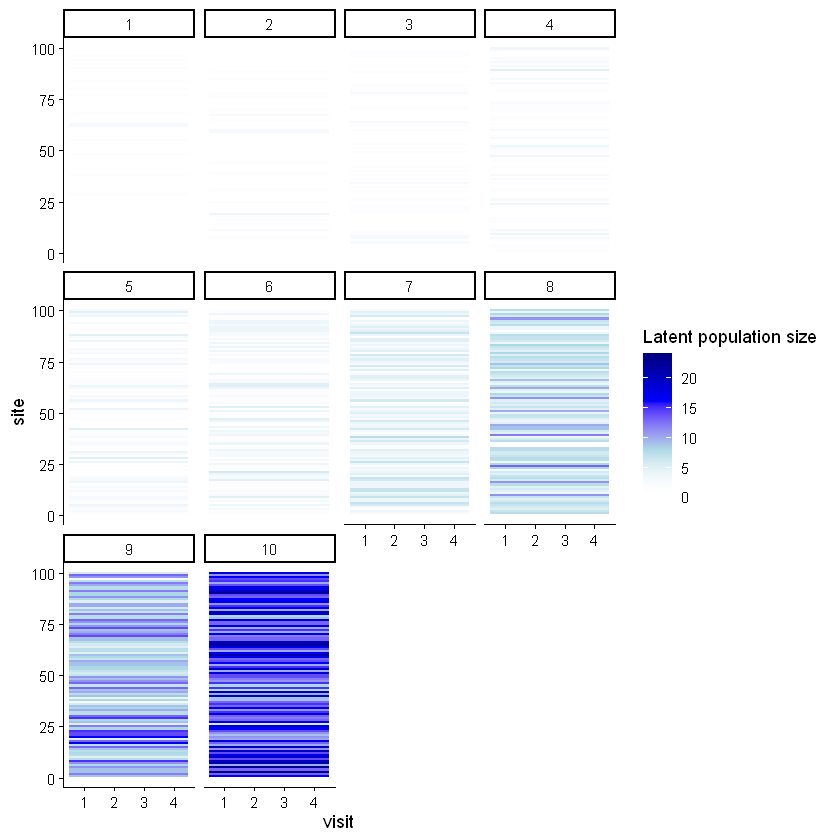

In [25]:
p1 <- ggplot(data = df) +
    geom_tile(aes(x = visit, y = site, fill = z)) + 
    scale_fill_gradientn(name = "Latent population size", colours = c("transparent", "lightblue", "blue", "navy")) + 
    theme_classic() + 
    facet_wrap(vars(year))
p1

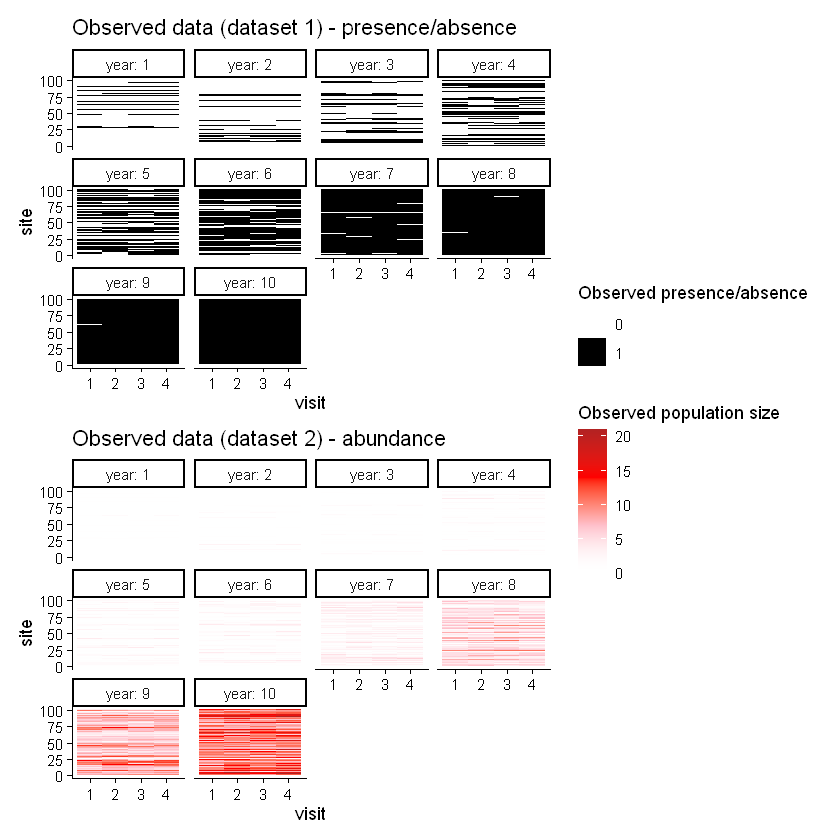

In [26]:
p2df1 <- ggplot(data = df %>% filter(dataset == 1)) + 
    geom_tile(aes(x = visit, y = site, fill = factor(value))) + 
    scale_fill_manual(name = "Observed presence/absence", values = c("transparent", "black")) + 
    theme_classic() + 
    facet_wrap(vars(year), labeller = "label_both") + 
    ggtitle("Observed data (dataset 1) - presence/absence")

p2df2 <- ggplot(data = df %>% filter(dataset == 2)) +
    geom_tile(aes(x = visit, y = site, fill = value)) + 
    scale_fill_gradientn(name = "Observed population size", colours = c("transparent", "pink", "red", "firebrick")) + 
    theme_classic() + 
    facet_wrap(vars(year), labeller = "label_both") + 
    ggtitle("Observed data (dataset 2) - abundance")

p2df1 / p2df2 + 
    plot_layout(guides = "collect")


Now that we have simulated both presence/absence and abundance data from the same latent state process, we can use a similar modelling approach as in example 4 to analyse both datasets separately. Dataset 1 will be individually modelled using an occupancy model, while dataset 2 will be modelled using an N-mixture model. The combined dataset will be modelled using a mixture model that allows both datasets to inform the latent population size and probability of detection, but respects the different data types of each dataset. The JAGS models used in this example can be found in the appendices. Again, for the sake of brevity we will jump straight to the model comparison code and output.

The model formulation for the occupancy model used to analyse the data in dataset 1 is the same as that in @eq-occ-model1. The model formulation for the N-mixture model used to analyse the data from dataset 2 is:

$$
\begin{aligned}
    y_{t, j, i} &\sim \mathrm{Binomial}(z_{t, j}, p)\\
    z_{t, j} &\sim \mathrm{Poisson}(\lambda_t)\\
    \mathrm{log}(\lambda_t) &= \alpha + \beta t \\
    \alpha &\sim \mathrm{Normal}(0, 1) \\
    \beta &\sim \mathrm{Normal}(0, 1) \\
    \mathrm{logit}(p) &\sim \mathrm{Normal}(0, 1) \\
\end{aligned}
$$ {#eq-nmix-model}

where $\lambda_t$ is the expected latent population size at time $t$.

The model formulation for the mixture model used to analyse the data from both dataset 1 and dataset 2 in this example is:

$$
\begin{aligned}
    y_{d, t, j, i} &\sim 
    \begin{cases} 
        \mathrm{Bernoulli}(1 - (1 - p)^{z_{t, j}}) & \text{if } d = 1 \\
        \mathrm{Binomial}(z_{t, j}, p) & \text{if } d = 2 \\
    \end{cases}\\
    z_{t, j} &\sim \mathrm{Poisson}(\lambda_t)\\
    \mathrm{log}(\lambda_t) &= \alpha + \beta t \\
    \alpha &\sim \mathrm{Normal}(0, 1) \\
    \beta &\sim \mathrm{Normal}(0, 1) \\
    \mathrm{logit}(p) &\sim \mathrm{Normal}(0, 1) \\
\end{aligned}
$$ {#eq-mixmodel}


In [29]:
set.seed(24601)

#subset to each dataset

df1 <- filter(df, dataset == 1)

y1 <- array(
    dim = c(length(unique(df1$dataset)), max(df1$year), max(df1$site), max(df1$visit))
)

for(i in 1:nrow(df1)) { # convert observations into 4-dimensional array
    y1[df1$dataset[i], df1$year[i], df1$site[i], df1$visit[i]] <- df1$value[i]
}

data_list_1 <- list( # create datalist
    n_datasets = dim(y1)[1],
    n_years = dim(y1)[2], 
    n_sites = dim(y1)[3], 
    n_visits = dim(y1)[4], 
    y = y1
)

# calculate initial values for z (latent occupancy state)
z_inits_1 <- apply(y1, c(2, 3), max, na.rm = TRUE) # compute max detection for each year and site
z_inits_1[is.na(z_inits_1) | z_inits_1 == -Inf] <- 1 # if all visits were NA, default to 1 (or 0)

inits_1 <- function() list( #create list of initial values
    z = z_inits_1,
    alpha = 0 ,
    beta = 0,
    p = 0
)

parameters <- c("alpha", "beta", "p", "log_lik") #parameters to be monitored

ni <- 20000;  nb <- 10000;  nt <- 10;  nc <- 4 # MCMC settings

samples1 <- jags( #run model
    model.file="jags_occ_model.bugs", 
    data=data_list_1, 
    inits=inits_1, 
    parameters.to.save=parameters, 
    n.iter=ni, 
    n.burnin=nb, 
    n.thin=nt,
    n.chains=nc, 
    parallel = T, 
    verbose = F
)

# jagsUI::traceplot(samples1, parameters = c("alpha", "beta", "p")) #inspect traceplot (not run here)
# samples1$summary #inspect model output (not run here)
# samples1$Rhat #inspect r-hat (not run here)


# filter data to dataset 2

df2 <- filter(df, dataset == 2)

y2 <- array(
    dim = c(length(unique(df2$dataset)), max(df2$year), max(df2$site), max(df2$visit))
)

for(i in 1:nrow(df2)) {
    y2[df2$dataset[i] - 1, df2$year[i], df2$site[i], df2$visit[i]] <- df2$value[i]
}

#create datalist
data_list_2 <- list(
    n_datasets = dim(y2)[1],
    n_years = dim(y2)[2], 
    n_sites = dim(y2)[3], 
    n_visits = dim(y2)[4], 
    y = y2
)

z_inits_2 <- apply(y2, c(2, 3), max, na.rm = TRUE)
z_inits_2[is.na(z_inits_2) | z_inits_2 == -Inf] <- 1

inits_2 <- function() list(
    z = z_inits_2,
    alpha = 0, 
    beta = 0,
    p = 0
)

samples2 <- jags(
    model.file="n_mix_model.bugs", 
    data=data_list_2, 
    inits=inits_2, 
    parameters.to.save=parameters, 
    n.iter=ni, 
    n.burnin=nb, 
    n.thin=nt,
    n.chains=nc, 
    parallel = T, 
    verbose = F
)

# jagsUI::traceplot(samples2, parameters = c("alpha", "beta", "p"))
# samples2$summary
# samples2$Rhat


# run model on combined data
yc <- array(
    dim = c(length(unique(df$dataset)), max(df$year), max(df$site), max(df$visit))
)

for(i in 1:nrow(df)) {
    yc[df$dataset[i], df$year[i], df$site[i], df$visit[i]] <- df$value[i]
}

# create datalist
data_list_c <- list(
    n_datasets = dim(yc)[1],
    n_years = dim(yc)[2], 
    n_sites = dim(yc)[3], 
    n_visits = dim(yc)[4], 
    y = yc
)

# define initial values and settings for MCMC
# compute max detection for each year and site
z_inits_c <- apply(yc[2, , , ], c(1, 2), function(x) {
    m <- suppressWarnings(max(x, na.rm = TRUE))
    if(!is.finite(m) || m < 1) return(1) else return(m + 1)
})


inits_c <- function() list(
    z = z_inits_c,
    alpha = rnorm(1, 0, 1), 
    beta = rnorm(1, 0, 1),
    p = 0
)

# run model

samplesc <- jags(
    model.file="combined_model.bugs", 
    data=data_list_c, 
    inits=inits_c, 
    parameters.to.save=parameters, 
    n.iter=ni, 
    n.burnin=nb, 
    n.thin=nt,
    n.chains=nc, 
    parallel = T, 
    verbose = F
)

# jagsUI::traceplot(samplesc, parameters = c("alpha", "beta", "p"))
# samplesc$summary

# Rhat (Brooks-Gelman-Rubin convergence statistic)
# samplesc$Rhat

In [30]:
# extract log-likelihood for each visit for each site for each dataset
log_lik_1 <- matrix(samples1$sims.list$log_lik, nrow = dim(samples1$sims.list$log_lik)[1])
loo_1 <- loo::loo(log_lik_1, cores = 4)

log_lik_2 <- matrix(samples2$sims.list$log_lik, nrow = dim(samples2$sims.list$log_lik)[1])
loo_2 <- loo::loo(log_lik_2, cores = 4)

log_lik_c <- matrix(samplesc$sims.list$log_lik, nrow = dim(samplesc$sims.list$log_lik)[1])
loo_c <- loo::loo(log_lik_c, cores = 4)


# extract and compare pointwise elpd estimates
elpd_1 <- cbind(
    loo_1$pointwise[, "elpd_loo"], 
    loo_c$pointwise[df$dataset == 1, "elpd_loo"]
)

elpd_2 <- cbind(
    loo_2$pointwise[, "elpd_loo"], 
    loo_c$pointwise[df$dataset == 2, "elpd_loo"]
)

pbma_wts_1 <- loo::pseudobma_weights(elpd_1)
names(pbma_wts_1) <- c("model 1", "combined model")
round(pbma_wts_1, 3)

pbma_wts_2 <- loo::pseudobma_weights(elpd_2)
names(pbma_wts_2) <- c("model 2", "combined model")
round(pbma_wts_2, 3)

Warning message:
"Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
"
Warning message:
"Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
"
Warning message:
"Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
"


Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 1        0.000 
combined model 1.000 

Method: pseudo-BMA+ with Bayesian bootstrap
------
               weight
model 2        0.002 
combined model 0.998 

With this example, we have demonstrated that this technique can be used to compare model performance across datasets with differing data structure (e.g. presence/absence and abundance) and therefore different likelihoods. This can be done because comparisons are being made *within* datasets and between models. It should be noted however that if the assumed distribution for a given dataset is different between the individual model and the combined model (e.g. when modelled individually a Poisson distribution is assumed, but when modelled in a combined model a negative-binomial distribution is assumed), these model performances cannot be compared using this method as the two likelihoods are not comparable.

## Discussion

This document explores data integration across a spectrum of complexity from linear regressions to occupancy and N-mixture models. Across these scenarios, evaluating leave-one-out predictive performance (via ELPD and LOOIC) and calculating Pseudo-BMA weights offers an empirical framework for answering the critical question: <b>Does adding another dataset actually improve our ability to predict in our system, or does it just introduce noise and bias?</b>

In this framework, we suggest model weights can be used as a diagnostic metric to evaluate the value of data integration. If an integrated model receives near-zero weights compared to individual models, this should act as a red flag that the data integration strategy that has been tested has failed. This should prompt either a re-specification of the observation process or the decision to analyze and predict from the datasets independently.

From the examples outlined above, we show that when datasets share an underlying state process and the combined model explicitly accounts for differences in the observation process (such as dataset-specific noise levels or varying detection probabilities), data integration often outperforms individual models. This is true in examples 1, 2, 4, and 5 (with the exception of dataset 2 in example 4). The combined model leverages the shared latent structure to contract parameter uncertainty, improving out-of-sample prediction accuracy, and earning high Pseudo-BMA weights. When datasets disagree on the state process itself (whether due to unmodelled spatial or temporal bias, conflicting environmental responses, etc.) data integration can be less useful than modelling datasets individually. If a combined model structure forces a single latent process across incompatible data (example 3), the combined model fits neither dataset well and can predict neither dataset well. In these cases, Pseudo-BMA weights shift heavily back toward the separate models, signalling that the datasets should not be combined without addressing the underlying conflict.

It should be noted that LOOIC assumes that data points are conditionally independent given the parameters. Because ecological and monitoring data frequently exhibit spatial, temporal, or observer-level autocorrelation, standard LOOIC can yield overly optimistic predictive scores. In these cases, blocked LOOIC (e.g., leaving out entire sampling years, spatial grid cells, or regions) to evaluate true out-of-sample predictive power should be considered.

## Appendices

### Script for checking prior distributions

```
#check priors
#p_det
p_det_pri_mean <- 0 #mean parameter for prob of detection
p_det_pri_sd <- 1.2 #sd parameter for prob of detection
hist(inv_logit(rnorm(1e4, p_det_pri_mean, p_det_pri_sd))) #visualise prior on prob of detection

#p_occ
alpha_pri_mean <- 0 #mean parameter for intercept of prob of occupancy
alpha_pri_sd <- 0.75 #sd parameter for intercept of prob of occupancy

pred_pri_mean <- 0 #mean parameter for effect size of predictor(s)
pred_pri_sd <- 0.4 #sd parameter for effect size of predictor(s)

#prior predictive check
prior_dist <- c()
for(i in 1:nrow(df)) {
    pp <- inv_logit(rnorm(100, alpha_pri_mean, alpha_pri_sd) + rnorm(100, pred_pri_mean, pred_pri_sd)*df$year[i])
    prior_dist <- append(prior_dist, pp)
}

hist(prior_dist) #visualise joint prior on all possible prior-predicted probability of occupancies
```

### JAGS occupancy model

```
model {
  # Priors
  for(i in 1:n_years) {
    logit(psi[i]) <- alpha + beta * i
  }
  alpha ~ dnorm(0, 1.77)
  beta ~ dnorm(0, 6.25)

  for(i in 1:n_datasets) {
    logit(p_link[i]) <- p[i]
    p[i] ~ dnorm(0, 0.6944) 
  }
  
  # Likelihood
  for(i in 1:n_years){
    for(s in 1:n_sites){
      # State model
      z[i, s] ~ dbern(psi[i]) #probability of occupancy
      for(d in 1:n_datasets){
        for(v in 1:n_visits){
          # Observation model
          p_obs[d, i, s, v] <- p_link[d] * z[i, s]
          y[d, i, s, v] ~ dbern(p_obs[d, i, s, v]) #probability of detection and occ
          log_lik[d, i, s, v] <- logdensity.bern(y[d, i, s, v], p_obs[d, i, s, v])
        }
      }
    }
  }
}
```

### JAGS N-mixture model

```
model {
  #Priors
  for(i in 1:n_years) {
      log(lambda[i]) <- alpha + beta * i
  }
  alpha ~ dnorm(0, 1)
  beta ~ dnorm(0, 1)

  logit(p_det) <- p
  p ~ dnorm(0, 1)

  #Likelihood
  for(i in 1:n_years){
    for(s in 1:n_sites){
    # State model
    z[i, s] ~ dpois(lambda[i]) #latent population size
      for(d in 1:n_datasets){
        for(v in 1:n_visits){
          # Observation model
          y[d, i, s, v] ~ dbinom(p_det, z[i, s])
          log_lik[d, i, s, v] <- logdensity.bin(y[d, i, s, v], p_det, z[i, s])
        }
      }
    }
  }
}
```

### JAGS mixture model

```
model {
    # Priors
    for(i in 1:n_years) {
        log(lambda[i]) <- alpha + beta * i
    }
    alpha ~ dnorm(0, 1)
    beta ~ dnorm(0, 1)


    logit(p_det) <- p
    p ~ dnorm(0, 1)
    
    # Likelihood
    for(i in 1:n_years){
        for(s in 1:n_sites){
            # Latent population size
            z[i, s] ~ dpois(lambda[i])

            # Observation model
            p_obs[i, s] <- (1 - ((1 - p_det)^z[i, s]))
            for(v in 1:n_visits){
                # Success probability
                y[1, i, s, v] ~ dbern(p_obs[i, s]) #probability of detection and occ
                log_lik[1, i, s, v] <- logdensity.bern(y[1, i, s, v], p_obs[i, s])
            }

            for(v in 1:n_visits){
                y[2, i, s, v] ~ dbinom(p_det, z[i, s])
                log_lik[2, i, s, v] <- logdensity.bin(y[2, i, s, v], p_det, z[i, s])
            } 
        }
    }
}
```